[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/FFTjax/blob/main/notebooks/pff-damage.ipynb)

# Phase-Field Fracture on a Real 3-Phase Microstructure Patch

A walkthrough of FFTjax's staggered phase-field fracture solver
(`solvers.mechanical.strain_nw_cg.solve_elastic` + `solvers.damage.pff_damage.solve_helmholtz_cg_het`)
on a **real, segmented composite microstructure** instead of an idealized sphere or square-packed
fibre pattern -- a 512x512x1 voxel patch cropped from a scanned/simulated carbon-fibre/epoxy
composite, with three phases (matrix, interphase, fibre) and a per-voxel fibre orientation field.

The patch is one of 2250 in `data/patches_fft/` (kept outside the repo -- see
`data/microstructures/README` -- copied into `data/microstructures/` for this example), each
tagged with its fibre+interphase volume fraction `phi` in the filename. This one has
`phi ~ 0.59`, picked at random among the patches close to `phi = 0.6`.

Material constants and phase-field parameters below are the same ones already used in
`configs/pff_prototype.yaml`, the project's reference config for this exact dataset -- see that
file for the full production setup (adaptive timestepper, YAML-driven, XDMF output). This notebook
strips that down to a minimal, directly-runnable walkthrough.

## Setup

In [3]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running on Colab — installing FFTjax...")
    %pip install -q git+https://github.com/choROPeNt/FFTjax.git
else:
    print("Running locally — using the local src/ checkout.")
    import sys
    sys.path.insert(0, "../src")

Running locally — using the local src/ checkout.


In [4]:
import utils.precision  # side effect: configures JAX (X64 off on TPU, no GPU prealloc)
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from mat_models.elastic import (
    LinearElasticIsotropic, TransverseIsotropicFibre,
    assemble_C_field_oriented, lame_from_C_field, strain_energy_amor_split,
)
from operators.green import build_freq_grid, build_green_operator
from solvers.mechanical.strain_nw_cg import solve_elastic
from solvers.damage.pff_damage import degradation, update_history_hybrid, solve_helmholtz_cg_het
from post.fields import field_to_grid, von_mises
from post.io import IncrementalWriter, to_voigt

print("JAX backend:", jax.default_backend())
print("Devices:", jax.devices())
print("X64 enabled:", utils.precision.X64_ENABLED,
      "-> dtype:", jnp.zeros(1).dtype)

JAX backend: cpu
Devices: [CpuDevice(id=0)]
X64 enabled: True -> dtype: float64


## Load the microstructure patch

Phase labeling in this dataset: `0 = matrix`, `1 = interphase`, `2 = fibre` (matches
`configs/pff_prototype.yaml`'s `fiber_phase: 2`). `orientation` gives the local fibre direction
per voxel -- unlike the idealized square-packed examples elsewhere in this repo, real fibre
cross-sections are not perfect circles and their in-plane orientation varies voxel to voxel.

In [5]:
patch_path = "../data/microstructures/patch_0772_phi0.5943.npz"

data = np.load(patch_path)
n = tuple(int(v) for v in data["n"])
L = tuple(float(v) for v in data["L"])
phase_np = data["phase"].reshape(-1)
orientation_np = data["orientation"].reshape(-1, 3).T   # (3, Nv)
phi = float(data["phi"])
Nv = int(np.prod(n))
dx = tuple(Li / ni for Li, ni in zip(L, n))

print("grid n :", n)
print("domain L [mm]:", L)
print("phi (fibre+interphase volume fraction):", phi)
print("phase fractions -- matrix:", float((phase_np == 0).mean()),
      " interphase:", float((phase_np == 1).mean()),
      " fibre:", float((phase_np == 2).mean()))

grid n : (512, 512, 1)
domain L [mm]: (0.059846144, 0.059846144, 0.000116887)
phi (fibre+interphase volume fraction): 0.5943031311035156
phase fractions -- matrix: 0.418548583984375  interphase: 0.078582763671875  fibre: 0.50286865234375


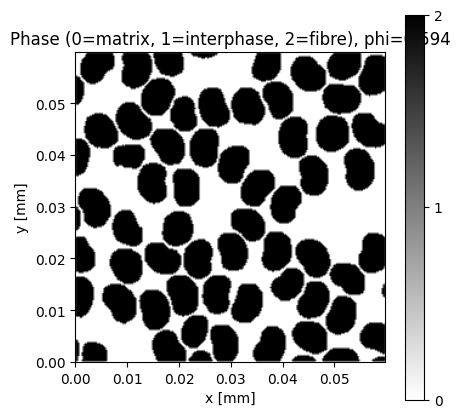

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(phase_np.reshape(n)[:, :, 0].T, origin="lower", cmap="grey_r",
               extent=[0, n[0]*dx[0], 0, n[1]*dx[1]])
ax.set_title(f"Phase (0=matrix, 1=interphase, 2=fibre), phi={phi:.3f}")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
fig.colorbar(im, ax=ax, ticks=[0, 1, 2])
plt.show()

## Materials and stiffness field

Same constants as `configs/pff_prototype.yaml`: an epoxy matrix, an interphase layer (using this
dataset's own calibrated modulus, `E_inter_MPa` from `data/patches_fft/index.json`, rather than
the config's rough placeholder), and a transversely isotropic carbon fibre. The fibre's transverse
constants (`E_T`, `G_LT`, `nu_LT`, `nu_TT`) aren't in the patch metadata (only `E_L` is), so they're
the same typical carbon-fibre literature values already used in that config.

`assemble_C_field_oriented` rotates the fibre's stiffness tensor per voxel using the patch's own
`orientation` field, instead of assuming a single global fibre direction.

In [8]:
matrix = LinearElasticIsotropic(E=3500.0, nu=0.35, name="epoxy matrix")
interphase = LinearElasticIsotropic(E=28372.521918222214, nu=0.35, name="interphase")
fiber = TransverseIsotropicFibre(
    E_L=230000.0, E_T=15000.0, G_LT=15000.0, nu_LT=0.20, nu_TT=0.30, name="carbon fibre",
)

phase = jnp.array(phase_np)
orientation = jnp.array(orientation_np)
matrix_mask = phase == 0
interphase_mask = phase == 1
damage_zone = matrix_mask | interphase_mask   # fibre never damages

C_field = assemble_C_field_oriented([matrix, interphase, fiber], phase, orientation)
lam_vox, mu_vox = lame_from_C_field(C_field)

print(matrix)
print(interphase)
print(fiber)

LinearElasticIsotropic (epoxy matrix): E=3.5e+03, nu=0.35, lam=3.02e+03, mu=1.3e+03
LinearElasticIsotropic (interphase): E=2.84e+04, nu=0.35, lam=2.45e+04, mu=1.05e+04
TransverseIsotropicFibre (carbon fibre): E_L=2.3e+05  E_T=1.5e+04  G_LT=1.5e+04  G_TT=5.77e+03  nu_LT=0.2  nu_TT=0.3


## Frequency grid, Green's operator, and AT2 parameters

Reference medium is the (matrix, fibre) Lame-parameter average, matching the other composite
examples. `Gc_field` is heterogeneous: the interphase cracks more easily than the matrix
(`Gc_interphase < Gc_mat`), and the fibre's toughness is set high enough that it doesn't crack
under the strains applied here -- the same values as `configs/pff_prototype.yaml`.

In [9]:
xi_flat = build_freq_grid(n, L)

lam0 = 0.5 * (matrix.lam + fiber.stiffness_tensor()[2, 2, 2, 2])
mu0 = 0.5 * (matrix.mu + fiber.G_LT)
G_glob = build_green_operator(xi_flat, lam0, mu0, scheme="rotated", dx=dx)

l0 = 3.0 * dx[0]
Gc_mat = 0.8e-3
Gc_interphase = 0.4e-3
Gc_yarn = Gc_mat * 2.0
Gc_field = jnp.where(matrix_mask, Gc_mat, jnp.where(interphase_mask, Gc_interphase, Gc_yarn))

print("l0 [mm]:", l0)
print("Gc_field [MPa.mm] -- matrix:", Gc_mat, " interphase:", Gc_interphase, " fibre:", Gc_yarn)

l0 [mm]: 0.000350661
Gc_field [MPa.mm] -- matrix: 0.0008  interphase: 0.0004  fibre: 0.0016


## Staggered load-stepping loop

Uniaxial tension along x, ramped up over a handful of strain increments (see `configs/pff_prototype.yaml`
for the full adaptive-timestepper version up to `eps_goal=1e-2`; this notebook uses a fixed, coarser
ramp to keep it a quick, directly-runnable walkthrough). Each increment alternates a mechanical
solve (matrix+interphase stiffness degraded by the current damage) and a Helmholtz damage solve
with `update_history_hybrid` irreversibility, until the damage field stops changing.

In [11]:
TOLER_LIN = 1e-2
TOLER_HELM = 1e-3
MAXITER_CG = 200
MAXITER_HELM = 200
MAXITER_STAGGER = 30
TOLER_STAGGER = 1e-2

d_field = jnp.zeros(Nv)
H_field = jnp.zeros(Nv)
eps_dir = jnp.array([[1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
strain_levels = np.linspace(1.0e-3, 5.0e-3, 20)

results = []
for k, eps_scale in enumerate(strain_levels):
    eps_bar = float(eps_scale) * eps_dir
    d_st = d_field
    for it_st in range(1, MAXITER_STAGGER + 1):
        d_prev = d_st

        g = jnp.where(damage_zone, degradation(d_st), 1.0)
        C_eff = g[None, None, None, None, :] * C_field

        eps, sigma, delta, conv_mech = solve_elastic(
            n, C_eff, G_glob, eps_bar, toler_lin=TOLER_LIN, maxiter=MAXITER_CG,
        )

        psi_pos, _ = strain_energy_amor_split(eps, lam_vox, mu_vox)
        psi_pos = jnp.where(damage_zone, psi_pos, 0.0)
        H_field = update_history_hybrid(H_field, psi_pos, d_prev)

        d_new, conv_helm = solve_helmholtz_cg_het(
            H_field, xi_flat, n, l0, Gc_field, d_prev, toler_cg=TOLER_HELM, maxiter=MAXITER_HELM,
        )
        d_st = d_new

        change = float(jnp.max(jnp.abs(d_st - d_prev)))
        if change < TOLER_STAGGER:
            break

    assert bool(conv_mech), f"mechanical CG did not converge at step {k+1}"
    d_field = d_st
    sigma11_ave = float(jnp.mean(sigma[0, 0]))
    results.append({"eps11": float(eps_scale), "sigma11_ave": sigma11_ave, "max_d": float(jnp.max(d_field))})
    print(f"step {k+1}/{len(strain_levels)}  eps11={float(eps_scale):.2e}  "
          f"sigma11_ave={sigma11_ave:8.3f} MPa  max(d)={float(jnp.max(d_field)):.4f}  "
          f"staggered_iters={it_st}")

print("\nPASSED -- mechanical CG converged at every step.")

step 1/20  eps11=1.00e-03  sigma11_ave=  10.223 MPa  max(d)=0.0147  staggered_iters=2
step 2/20  eps11=1.21e-03  sigma11_ave=  12.375 MPa  max(d)=0.0214  staggered_iters=1
step 3/20  eps11=1.42e-03  sigma11_ave=  14.489 MPa  max(d)=0.0297  staggered_iters=1
step 4/20  eps11=1.63e-03  sigma11_ave=  16.583 MPa  max(d)=0.0396  staggered_iters=1
step 5/20  eps11=1.84e-03  sigma11_ave=  18.574 MPa  max(d)=0.0524  staggered_iters=2
step 6/20  eps11=2.05e-03  sigma11_ave=  20.597 MPa  max(d)=0.0663  staggered_iters=2
step 7/20  eps11=2.26e-03  sigma11_ave=  22.601 MPa  max(d)=0.0833  staggered_iters=2
step 8/20  eps11=2.47e-03  sigma11_ave=  24.554 MPa  max(d)=0.1023  staggered_iters=2
step 9/20  eps11=2.68e-03  sigma11_ave=  26.463 MPa  max(d)=0.1239  staggered_iters=2
step 10/20  eps11=2.89e-03  sigma11_ave=  28.325 MPa  max(d)=0.1488  staggered_iters=2
step 11/20  eps11=3.11e-03  sigma11_ave=  30.134 MPa  max(d)=0.1774  staggered_iters=2
step 12/20  eps11=3.32e-03  sigma11_ave=  31.884 MPa

AssertionError: mechanical CG did not converge at step 19

## Visualize: macroscopic response and damage field

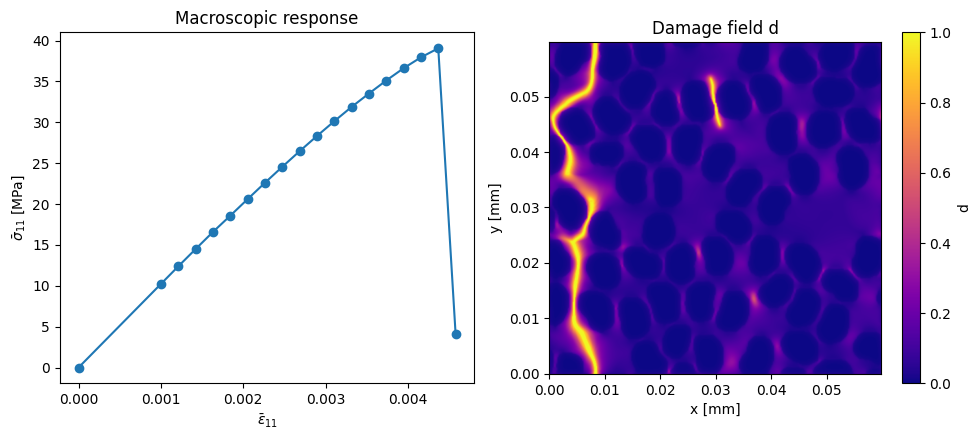

In [14]:
eps11 = [r["eps11"] for r in results]
sigma11 = [r["sigma11_ave"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].plot([0] + eps11, [0] + sigma11, "o-")
axes[0].set_xlabel(r"$\bar\varepsilon_{11}$")
axes[0].set_ylabel(r"$\bar\sigma_{11}$ [MPa]")
axes[0].set_title("Macroscopic response")

d_grid = np.asarray(d_field).reshape(n)
im = axes[1].imshow(d_grid[:, :, 0].T, origin="lower", vmin=0, vmax=1, cmap="plasma",
                     extent=[0, n[0]*dx[0], 0, n[1]*dx[1]])
axes[1].set_title("Damage field d")
axes[1].set_xlabel("x [mm]")
axes[1].set_ylabel("y [mm]")
fig.colorbar(im, ax=axes[1], label="d")

fig.tight_layout()
plt.show()

## Post-processing: export to XDMF/HDF5

Same field-writing convention as the rest of the project (`post.io.IncrementalWriter`), so the
result can be opened in ParaView (`Xdmf3ReaderT`) alongside the other examples' output.

In [ ]:
eps_grid = field_to_grid(eps, n)
sigma_grid = field_to_grid(sigma, n)
vm_grid = von_mises(sigma_grid)

output_dir = "../output"
import os
os.makedirs(output_dir, exist_ok=True)

with IncrementalWriter(f"{output_dir}/pff_damage_patch", grid_shape=n, grid_spacing=dx) as w:
    w.write_increment(0, {
        "phase":     phase_np.astype(np.float64).reshape(n),
        "strain":    to_voigt(eps_grid).astype(np.float64),
        "stress":    to_voigt(sigma_grid).astype(np.float64),
        "von_mises": vm_grid.astype(np.float64),
        "damage":    d_grid.astype(np.float64),
    }, time=0.0)

print(f"Wrote {output_dir}/pff_damage_patch.h5")
print(f"      {output_dir}/pff_damage_patch.xdmf")
print("Open the .xdmf in ParaView with the 'Xdmf3ReaderT' reader.")

## Next steps

- Try a different patch from `data/patches_fft/` -- volume fraction, fibre packing, and local
  orientation all vary between patches, so damage nucleation sites and the macroscopic response
  will differ.
- Compare against the idealized sphere-seed example in `examples/pff_damage.py` --
  real, sharp-interface microstructure typically shows more localized, geometry-driven
  damage nucleation than an idealized seed does.
- See `configs/pff_prototype.yaml` for the full production setup with an adaptive timestepper,
  driven via `scripts/simulation/pff_nw_cg_strain.py`.